## Import the libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error

import itertools

## Load Preprocessed Brent Daily Dataset

In [2]:
brent_daily = pd.read_csv(
    r"C:\Users\ranpa\Desktop\MSc in DS\Machine Learning\Coursework\Question_2\preprocessed_datasets\brent_daily_preprocessed.csv"
)

In [3]:
brent_daily.head()

,Date,Price,Rolling_Mean,Rolling_STD
0,1987-05-20,18.63,NaN,NaN
1,1987-05-21,18.45,NaN,NaN
2,1987-05-22,18.55,NaN,NaN
3,1987-05-25,18.60,NaN,NaN
4,1987-05-26,18.63,NaN,NaN


In [4]:
brent_daily["Date"] = pd.to_datetime(
    brent_daily["Date"]
)

brent_daily.set_index(
    "Date",
    inplace=True
)

In [5]:
brent_daily.head()

,Price,Rolling_Mean,Rolling_STD
Date,,,
1987-05-20,18.63,NaN,NaN
1987-05-21,18.45,NaN,NaN
1987-05-22,18.55,NaN,NaN
1987-05-25,18.60,NaN,NaN
1987-05-26,18.63,NaN,NaN


## Select the Target Variable

In [6]:
oil_price = brent_daily["Price"]

## Visualize the Series

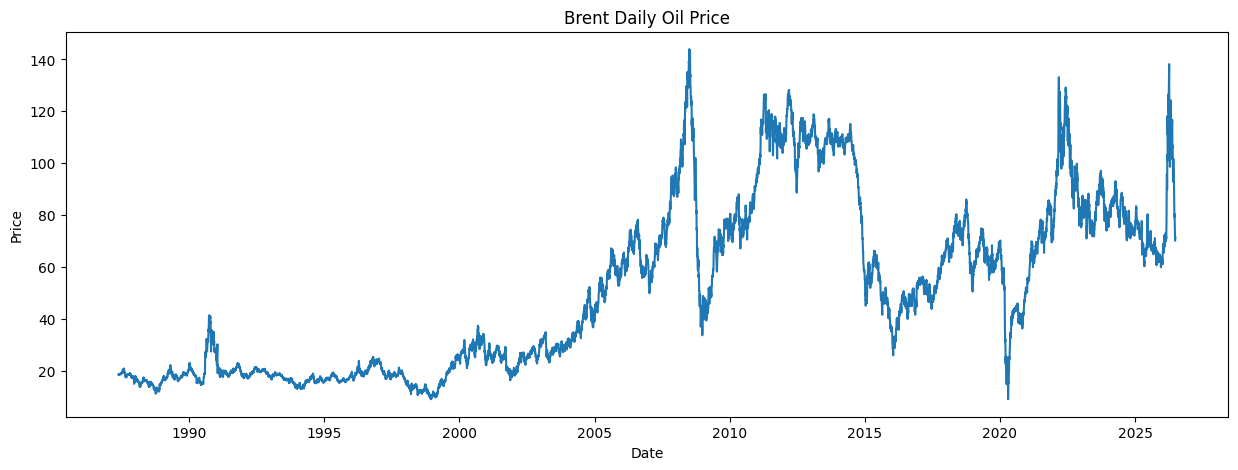

In [8]:
plt.figure(figsize=(15,5))

plt.plot(oil_price)

plt.title("Brent Daily Oil Price")

plt.xlabel("Date")

plt.ylabel("Price")

plt.show()

## Check the Stationarity

In [9]:
from statsmodels.tsa.stattools import adfuller


result = adfuller(oil_price)


print("ADF Statistic:", result[0])

print("p-value:", result[1])

ADF Statistic: -2.5180768722830655
p-value: 0.11113774896372974


Oil prices are non-stationary.

## Differencing

In [10]:
oil_diff = oil_price.diff()

oil_diff.dropna(inplace=True)

In [11]:
result = adfuller(oil_diff)

print(result[1])

7.621294758818647e-29


## Plot ACF and PACF

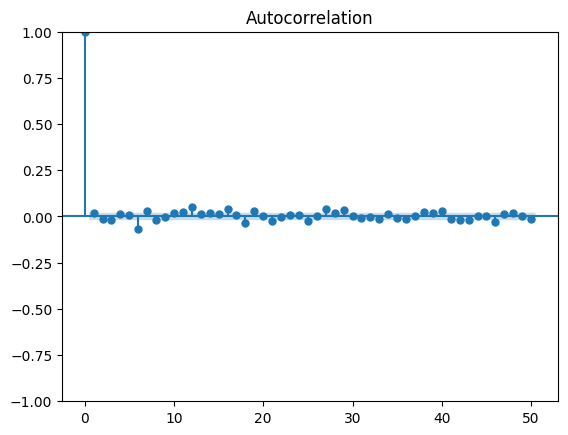

In [12]:
plot_acf(
    oil_diff,
    lags=50
)

plt.show()

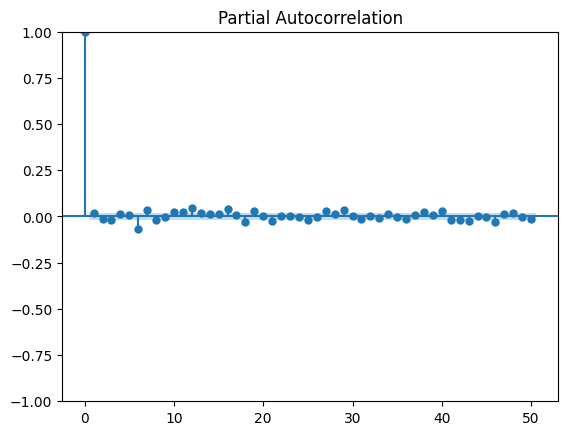

In [13]:
plot_pacf(
    oil_diff,
    lags=50
)

plt.show()

## Train-Test Split

In [14]:
train_size = int(len(oil_price)*0.8)


train = oil_price.iloc[:train_size]

test = oil_price.iloc[train_size:]

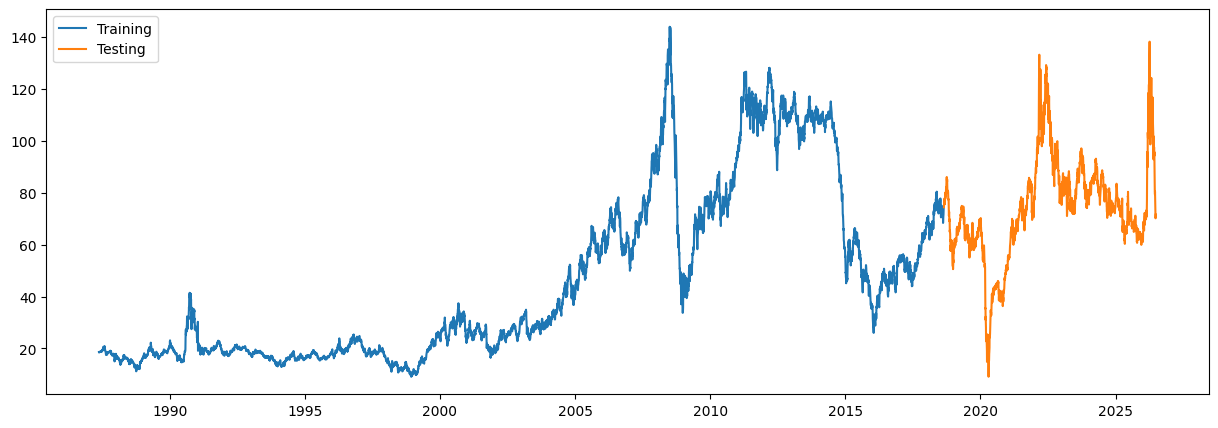

In [15]:
plt.figure(figsize=(15,5))

plt.plot(train,label="Training")

plt.plot(test,label="Testing")

plt.legend()

plt.show()

## Build Initial SARIMA Model

In [16]:
model = SARIMAX(
    train,
    order=(1,1,1),
    seasonal_order=(1,1,1,7),
    enforce_stationarity=False,
    enforce_invertibility=False
)


sarima_model = model.fit()


print(sarima_model.summary())

C:\Users\ranpa\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\ranpa\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                     
Dep. Variable:                             Price   No. Observations:                 7937
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 7)   Log Likelihood              -11739.713
Date:                           Wed, 29 Jul 2026   AIC                          23489.426
Time:                                   21:59:22   BIC                          23524.312
Sample:                                        0   HQIC                         23501.373
                                          - 7937                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0785      0.207     -0.379      0.704      -0.484       0.327
ma.L1          0.1112      0.206      0.539

In [17]:
forecast = sarima_model.forecast(
    steps=len(test)
)

C:\Users\ranpa\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\ranpa\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


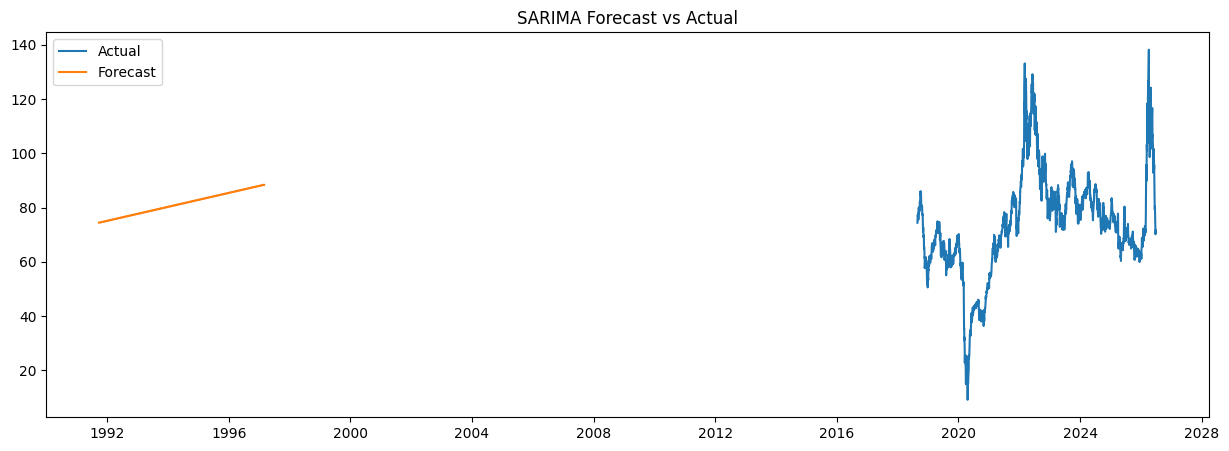

In [18]:
plt.figure(figsize=(15,5))


plt.plot(test,label="Actual")


plt.plot(
    forecast,
    label="Forecast"
)


plt.legend()


plt.title(
    "SARIMA Forecast vs Actual"
)


plt.show()

## Performance Evaluation

In [19]:
mae = mean_absolute_error(
    test,
    forecast
)

print("MAE:", mae)

MAE: 15.023173682465126


In [20]:
rmse = np.sqrt(
    mean_squared_error(
        test,
        forecast
    )
)

print("RMSE:", rmse)

RMSE: 19.468488023255855


In [21]:
mape = mean_absolute_percentage_error(
    test,
    forecast
)


print("MAPE:", mape)

MAPE: 0.2754673749509756


In [22]:
sarima_results = pd.DataFrame(
{
"Model":["SARIMA"],
"MAE":[mae],
"RMSE":[rmse],
"MAPE":[mape]
}
)

sarima_results

,Model,MAE,RMSE,MAPE
0,SARIMA,15.023174,19.468488,0.275467


## Hyperparameter Tuning

In [45]:
p = range(0,3)

d = range(0,2)

q = range(0,3)


pdq = list(
    itertools.product(
        p,d,q
    )
)

In [46]:
best_aic = np.inf

best_order = None


for param in pdq:

    try:

        model = SARIMAX(
            train,
            order=param,
            seasonal_order=(1,1,1,7),
            enforce_stationarity=False,
            enforce_invertibility=False
        )

        result = model.fit(disp=False)


        if result.aic < best_aic:

            best_aic=result.aic

            best_order=param


    except:
        continue


print(best_order)
print(best_aic)

C:\Users\ranpa\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(2, 1, 2)
23948.418832607465


## Train the final SARIMA model using best parameters

In [47]:
best_SARIMA = SARIMAX(
    train,
    order=best_order,
    seasonal_order=(2,1,2,7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

best_sarima_fit = best_SARIMA.fit()

print(best_sarima_fit.summary())

C:\Users\ranpa\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                                     SARIMAX Results                                     
Dep. Variable:                             Price   No. Observations:                11428
Model:             SARIMAX(2, 1, 2)x(2, 1, 2, 7)   Log Likelihood              -11961.058
Date:                           Wed, 29 Jul 2026   AIC                          23940.116
Time:                                   23:11:06   BIC                          24006.190
Sample:                               05-20-1987   HQIC                         23962.336
                                    - 09-01-2018                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2624      0.081     -3.247      0.001      -0.421      -0.104
ar.L2         -0.4448      0.068     -6.570

## Generate forecasts for the test period

In [48]:
best_forecast = best_sarima_fit.forecast(
    steps=len(test)
)

## Compare Actual vs Forecasted Values

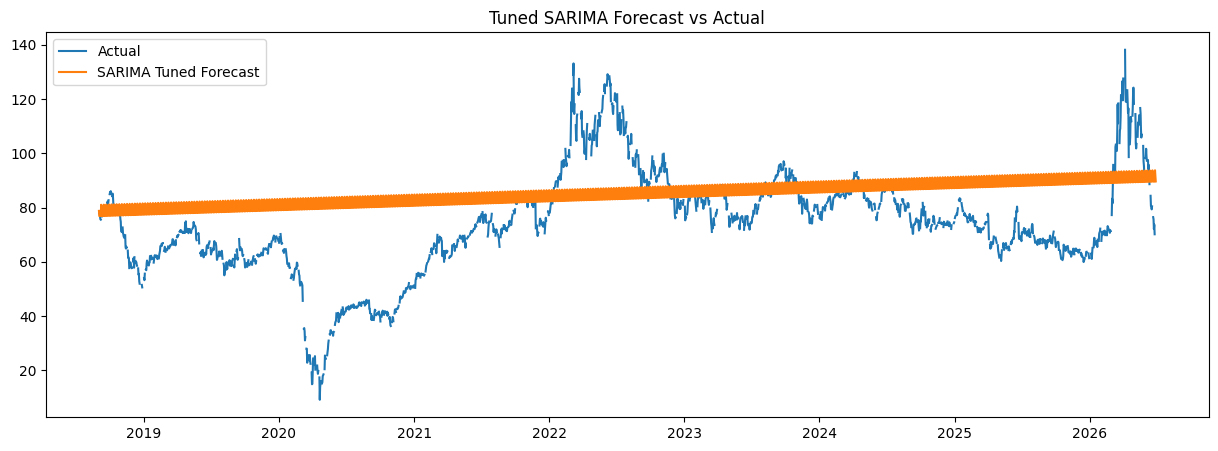

In [49]:
plt.figure(figsize=(15,5))

plt.plot(test,
         label="Actual")

plt.plot(best_forecast,
         label="SARIMA Tuned Forecast")

plt.legend()

plt.title(
    "Tuned SARIMA Forecast vs Actual"
)

plt.show()

## Calculate Forecast Accuracy Metrics

In [50]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np


mae = mean_absolute_error(
    test,
    best_forecast
)


rmse = np.sqrt(
    mean_squared_error(
        test,
        best_forecast
    )
)


mape = np.mean(
    np.abs(
        (test-best_forecast)/test
    )
)*100


print("MAE:",mae)
print("RMSE:",rmse)
print("MAPE:",mape)

ValueError: Input contains NaN.

## Check Residual Diagnostics

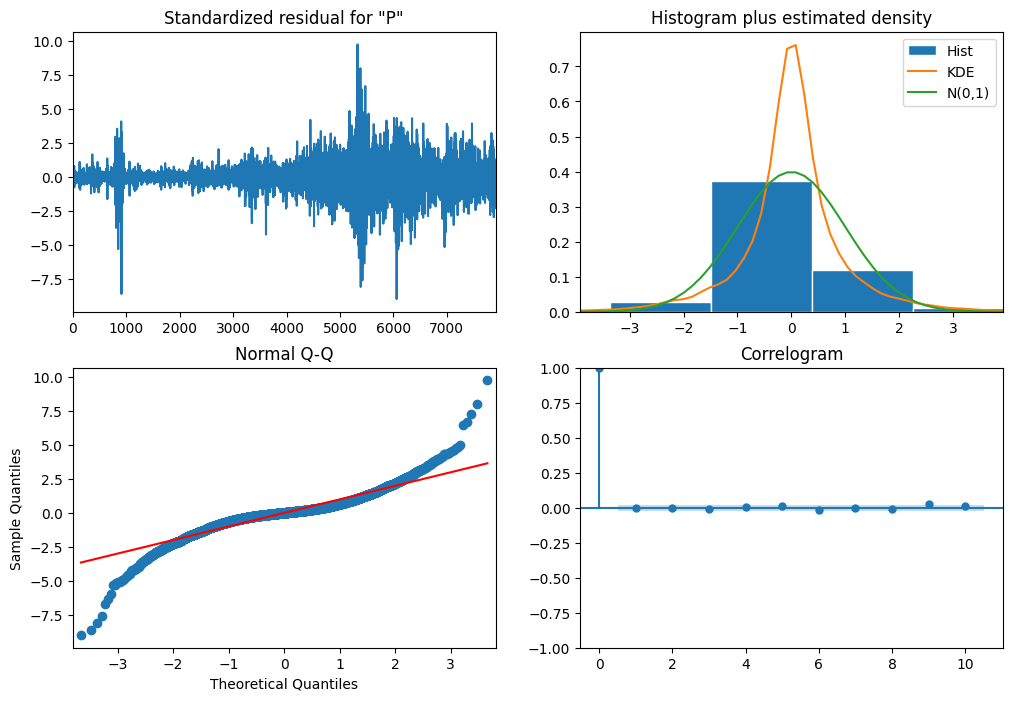

In [51]:
final_result.plot_diagnostics(figsize=(12,8))
plt.show()

## Forecast Future Oil Prices

In [34]:
final_full_model = SARIMAX(
    oil_price,
    order=best_order,
    seasonal_order=(0,1,2,7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

final_full_result = final_full_model.fit()

In [35]:
future_forecast = final_full_result.forecast(
    steps=30
)

print(future_forecast)

2026-06-30    71.508859
2026-07-01    71.422127
2026-07-02    71.513574
2026-07-03    71.496596
2026-07-04    71.492375
2026-07-05    71.488020
2026-07-06    71.481340
2026-07-07    71.458960
2026-07-08    71.440377
2026-07-09    71.510994
2026-07-10    71.541431
2026-07-11    71.529737
2026-07-12    71.518044
2026-07-13    71.506350
2026-07-14    71.484623
2026-07-15    71.466322
2026-07-16    71.536939
2026-07-17    71.567377
2026-07-18    71.555683
2026-07-19    71.543989
2026-07-20    71.532295
2026-07-21    71.510568
2026-07-22    71.492268
2026-07-23    71.562885
2026-07-24    71.593322
2026-07-25    71.581628
2026-07-26    71.569934
2026-07-27    71.558240
2026-07-28    71.536513
2026-07-29    71.518213
Freq: D, Name: predicted_mean, dtype: float64
